# Modeling: TF-IDF vs Skip-gram untuk Klasifikasi Berita

Notebook ini adalah kelanjutan dari Tugas 2 (Text Preprocessing). Dari
`data/dataset_berita_detik.csv` (200 artikel, 100 berlabel `sport` dan 100
berlabel `finance`), teks dibersihkan ulang secara lengkap, lalu diubah
menjadi dua representasi angka yang berbeda cara kerjanya:

1. **TF-IDF** — pendekatan berbasis hitungan kata. Setiap kata diberi bobot
   sesuai seberapa khas kemunculannya di satu dokumen dibanding dokumen lain.
2. **Skip-gram (Word2Vec)** — pendekatan berbasis makna. Model belajar
   memprediksi kata-kata di sekitar sebuah kata, sehingga kata yang sering
   muncul pada konteks mirip mendapat vektor yang berdekatan.

Kedua representasi dipasangkan dengan **Naive Bayes**, parameter masing-masing
dicari lewat **Grid Search** (pencarian kombinasi parameter secara sistematis,
diuji dengan cross-validation), lalu performanya dibandingkan di data uji yang
sama persis. Model dengan hasil terbaik disimpan ke berkas `.joblib` supaya
bisa dipakai ulang tanpa melatih dari awal.

Alur notebook:
`Data` → `Cleaning` → `Split` → `TF-IDF + Grid Search` → `Skip-gram + Grid
Search` → `Evaluation` → `Model Selection` → `Save Model` → `Conclusion`

## Data Loading

Dataset dimuat dari `data/dataset_berita_detik.csv`. Sebelum masuk ke
pembersihan, sebaran label diperiksa untuk memastikan data masih seimbang
seperti saat dikumpulkan di Tugas 1. Keseimbangan ini penting karena kalau satu
label jauh lebih banyak, model bisa "curang" dengan menebak label mayoritas
terus-menerus dan tetap terlihat akurat.

In [50]:
%pip install pandas matplotlib seaborn scikit-learn scipy Sastrawi indoNLP gensim joblib -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd


df = pd.read_csv("dataset_berita_detik.csv")

pd.DataFrame({
    "metrik": ["jumlah artikel", "label unik", "sport", "finance"],
    "nilai": [len(df), df["label"].nunique(),
              (df["label"] == "sport").sum(),
              (df["label"] == "finance").sum()],
})

,metrik,nilai
0,jumlah artikel,200
1,label unik,2
2,sport,100
3,finance,100


## Text Cleaning

Teks mentah dari hasil crawling detik.com masih membawa banyak hal yang bukan
isi berita sebenarnya: sisa antarmuka situs, tanda baca, angka, kata tidak
baku, dan variasi bentuk kata (imbuhan). Kalau dibiarkan, hal-hal ini
menambah kosakata secara tidak perlu dan membuat model sulit menemukan pola
yang sebenarnya membedakan sport dari finance.

Pembersihan dilakukan dalam tujuh langkah berurutan, masing-masing dijelaskan
di bagian tersendiri di bawah supaya alasan setiap langkah jelas:

1. Site Boilerplate Removal - buang sisa antarmuka situs.
2. Format Protection - lindungi URL, nominal uang, kode berangka, angka
   Romawi dari ikut terpotong.
3. Letter Normalization - samakan huruf beraksen ke bentuk ASCII biasa.
4. Slang Standardization - bakukan kata tidak baku, kecuali nama diri.
5. Punctuation & Number Stripping - buang tanda baca, angka, token terlalu
   pendek.
6. Stopword Removal - buang kata umum yang tidak membedakan topik.
7. Stemming with Name Protection - potong ke kata dasar, kecuali nama diri.

### Site Boilerplate Removal

Setiap artikel diakhiri frasa tetap `Anda menyukai artikel ini Artikel
disimpan`, kadang didahului kode redaksi dalam kurung seperti `(krs/nds)`.
Artikel foto juga diawali `Foto Sport` atau `Foto Finance`, kata yang sama
persis dengan nama label, sehingga kalau tidak dibuang justru bisa menjadi
petunjuk palsu yang membuat model terlihat pintar padahal hanya mengenali
kata label itu sendiri. Bagian-bagian ini dibuang lebih dulu sebelum langkah
lainnya.

In [14]:
import re

byline_re = r"\(\w{2,6}(?:/\w{2,6})+\)"
boiler_re = rf"(?:{byline_re}\s*)?Anda menyukai artikel ini\s+Artikel disimpan\s*$"
photo_re = r"^Foto\s+(?:Sport|Finance)\s+"


def strip_boilerplate(text):
    text = re.sub(photo_re, "", text)
    return re.sub(boiler_re, "", text).strip()


texts_clean = df["isi_berita"].map(strip_boilerplate)

pd.DataFrame({
    "id": df["id"].head(2),
    "sebelum (akhir teks)": df["isi_berita"].head(2).str[-60:],
    "sesudah (akhir teks)": texts_clean.head(2).str[-60:],
})

,id,sebelum (akhir teks),sesudah (akhir teks)
0,1,1 poin. (krs/nds) Anda menyukai artikel ini Ar...,ara Marco Bezzecchi berada di posisi ketiga de...
1,2,engejar prestasi. Anda menyukai artikel ini Ar...,enguatan fisik menjadi bagian dari proses meng...


### Format Protection

Sebelum tanda baca dan angka dibuang total, beberapa pola justru perlu
dilindungi utuh supaya nilainya tidak hancur jadi token acak:

- **URL** (`https://...`, `pic.twitter.com/...`) — kalau tidak dibuang
  sekaligus, sisa potongannya (misalnya `sport`, `detik`, `com`) akan ikut
  terhitung sebagai kata biasa dan mencemari kosakata.
- **Nominal uang** (`Rp1.000.000`, `US$500`) — penting secara makna untuk
  berita finance, tapi angkanya tidak berguna sebagai kata, jadi seluruh pola
  dibuang bersama simbolnya daripada dipotong setengah-setengah.
- **Kode alfanumerik** (`RS-GP26`, `3x3`) — gabungan huruf dan angka seperti
  ini, kalau hanya tanda baca yang dibuang, akan menyisakan pecahan aneh
  seperti `rs` dan `gp`.
- **Angka Romawi** (`II`, `III`) — sering muncul sebagai penomoran, bukan kata
  yang bermakna.

Keempatnya dicari dan dibuang (diganti spasi) sebelum tanda baca biasa
diproses, supaya yang tersisa untuk langkah tanda-baca hanyalah kata murni.

In [15]:
url_pattern = re.compile(r"(?:https?://|www\.|pic\.twitter\.com/)\S+")
alnum_pattern = re.compile(r"\b(?=[A-Za-z]*\d)[A-Za-z0-9][A-Za-z0-9.*-]*\b")
currency_pattern = re.compile(
    r"\bRp\d[\d.,]*\b|\bUS\$\d[\d.,]*\b|\b\$\d[\d.,]*\b|\bRp\b|\bUS\$\b")
roman_pattern = re.compile(
    r"\b(?:iii|iv|vi{0,3}|i[ivx]{0,2}|v|x{1,3}|xi{0,3})\b", re.IGNORECASE)


def protect(text):
    text = url_pattern.sub(" ", text)
    text = currency_pattern.sub(" ", text)
    text = alnum_pattern.sub(" ", text)
    text = roman_pattern.sub(" ", text)
    return text


n_url = sum(len(url_pattern.findall(t)) for t in texts_clean)
n_curr = sum(len(currency_pattern.findall(t)) for t in texts_clean)
n_alnum = sum(len(alnum_pattern.findall(t)) for t in texts_clean)
n_roman = sum(len(roman_pattern.findall(t)) for t in texts_clean)

pd.DataFrame({
    "pola": ["URL", "nominal uang", "kode alfanumerik", "angka Romawi"],
    "jumlah ditemukan": [n_url, n_curr, n_alnum, n_roman],
})

,pola,jumlah ditemukan
0,URL,4
1,nominal uang,225
2,kode alfanumerik,3508
3,angka Romawi,56


### Letter Normalization

Sebagian nama hasil transliterasi atau tanda baca sumber bisa memuat karakter
di luar huruf ASCII biasa (misalnya huruf beraksen atau tanda hubung khusus).
Kalau dibiarkan, karakter semacam ini akan dibuang begitu saja pada langkah
tanda-baca, membuat kata jadi terpotong aneh. Karakter aksen dilebur ke huruf
dasarnya terlebih dulu (misalnya menjadi huruf biasa), dan varian tanda
hubung disamakan ke tanda hubung standar.

In [16]:
import unicodedata


def normalize_letters(text):
    decomposed = unicodedata.normalize("NFD", text)
    text = "".join(c for c in decomposed if not unicodedata.combining(c))
    return text.replace("\u2011", "-").replace("\u2010", "-")


non_ascii_before = sum(any(ord(c) > 127 for c in t) for t in texts_clean)
after_normalize = [normalize_letters(protect(t)) for t in texts_clean]
non_ascii_after = sum(any(ord(c) > 127 for c in t) for t in after_normalize)

pd.DataFrame({
    "tahap": ["sebelum normalisasi", "sesudah normalisasi"],
    "artikel dengan karakter non-ASCII": [non_ascii_before, non_ascii_after],
})

,tahap,artikel dengan karakter non-ASCII
0,sebelum normalisasi,4
1,sesudah normalisasi,4


### Slang Standardization

Bahasa berita daring sering menyelipkan kata tidak baku atau singkatan
informal. Kamus `indoNLP` (`replace_slang`) dipakai untuk membakukan kata
semacam itu ke bentuk standarnya. Tapi kamus ini tidak tahu konteks, bisa saja
sebuah nama orang kebetulan mirip entri slang. Supaya nama tidak ikut
berubah, sebuah kata hanya dibakukan kalau semua syarat berikut terpenuhi:

- bukan termasuk daftar pengecualian manual (`excluded_slang`),
- tidak berdekatan dengan angka (tanda itu biasanya kode, bukan kata biasa),
- tidak terlihat seperti nama diri (diawali kapital di tengah kalimat, atau
  memuat huruf kapital di tengah kata),
- bukan token dua huruf yang sebenarnya kata fungsi valid.

Daftar `excluded_slang` berisi kata yang terbukti dari tahap sebelumnya rawan
salah ubah; nilainya hasil pemeriksaan manual pada dataset Anda, bukan
tebakan.

In [17]:
from indoNLP.preprocessing import replace_slang
from collections import Counter


def mid_sentence(text, pos):
    i = pos - 1
    while i >= 0 and text[i] in ' \n\t"\'":(':
        i -= 1
    return i >= 0 and text[i] not in '.!?;:(\u2013\u2014'


excluded_slang = {"minta", "pala", "fans"}
slang_changes = Counter()


def guarded_replace(text):
    changes = []
    for m in re.finditer(r"[A-Za-z]+", text):
        w = m.group(0)
        repl = replace_slang(w.lower())
        if repl == w.lower() or w.lower() in excluded_slang:
            continue
        before = text[max(0, m.start() - 6):m.start()]
        after = text[m.end():m.end() + 6]
        near_digit = bool(re.search(r"\d", before + after))
        looks_name = (w.isupper() or any(c.isupper() for c in w[1:])
                      or (w[:1].isupper() and w[1:].islower()
                          and mid_sentence(text, m.start())))
        two_letter = len(w) <= 2 and w.lower() not in id_stopwords_preview
        if not (near_digit or looks_name or two_letter):
            changes.append((m.start(), m.end(), repl))
            slang_changes[w.lower()] += 1
    out = list(text)
    for s, e, r in reversed(changes):
        out[s:e] = list(r)
    return "".join(out)

In [18]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

id_stopwords_preview = set(StopWordRemoverFactory().get_stop_words())
after_slang = [guarded_replace(t) for t in after_normalize]

pd.DataFrame([{"kata asli": w, "padanan baku": replace_slang(w),
               "kemunculan diubah": n}
              for w, n in slang_changes.most_common(10)])

,kata asli,padanan baku,kemunculan diubah
0,nggak,enggak,34
1,gitu,begitu,10
2,udah,sudah,9
3,kaya,kayak,7
4,hub,hubungan,4
5,gimana,bagaimana,3
6,slam,salam,3
7,aja,saja,3
8,ngomong,mengomong,2
9,ngantri,mengantri,2


### Punctuation & Number Stripping

Setelah pola-pola penting dilindungi dan kata dibakukan, barulah seluruh
tanda baca dan angka yang tersisa dibuang kasar, diganti spasi. Token yang
tersisa di bawah dua huruf juga dibuang, karena pada tahap eksplorasi
sebelumnya token sependek itu terbukti nyaris selalu berupa pecahan kata,
bukan kata utuh yang bermakna.

In [19]:
def strip_punct(text):
    text = re.sub(r"[^A-Za-z\s-]", " ", text)
    text = re.sub(r"-+", " ", text)
    return [w for w in text.split() if len(w) >= 2]


tokens_stage1 = [strip_punct(t) for t in after_slang]

pd.DataFrame({
    "metrik": ["token total", "kata unik"],
    "nilai": [sum(len(d) for d in tokens_stage1),
              len({w.lower() for d in tokens_stage1 for w in d})],
})

,metrik,nilai
0,token total,64262
1,kata unik,7238


### Stopword Removal

Stopword adalah kata fungsi yang muncul di hampir semua dokumen tanpa
membawa makna topik, misalnya *yang*, *di*, *dan*, *untuk*. Kata semacam ini
hadir rata di berita sport maupun finance, sehingga tidak membantu model
membedakan keduanya, justru hanya menambah ukuran kosakata. Daftar stopword
Sastrawi dipakai untuk membuang kata-kata ini.

In [20]:
tokens_stage2 = [[w for w in d if w.lower() not in id_stopwords_preview]
                 for d in tokens_stage1]
removed_stopwords = Counter(
    w.lower() for d in tokens_stage1 for w in d
    if w.lower() in id_stopwords_preview)

pd.DataFrame({
    "metrik": ["token sebelum", "token sesudah", "stopword dibuang"],
    "nilai": [sum(len(d) for d in tokens_stage1),
              sum(len(d) for d in tokens_stage2),
              sum(removed_stopwords.values())],
})

,metrik,nilai
0,token sebelum,64262
1,token sesudah,48498
2,stopword dibuang,15764


### Name Protection

Sebelum stemming (pemotongan ke kata dasar) dijalankan, nama diri perlu
diamankan lebih dulu. Stemmer tidak tahu mana nama orang dan mana kata biasa;
tanpa perlindungan, nama bisa berubah bentuk (misalnya nama yang kebetulan
mirip pola imbuhan Indonesia ikut terpotong), padahal nama seharusnya tidak
pernah diubah.

Kata diperlakukan sebagai nama diri kalau terdeteksi berulang kali ditulis
berkapital di tengah kalimat (bukan di awal kalimat, karena awal kalimat
selalu berkapital terlepas dari jenis katanya). Ambang yang dipakai: minimal
lima kemunculan berkapital tengah kalimat, dan proporsi kemunculan berkapital
itu minimal separuh dari seluruh kemunculan kata tersebut (supaya kata biasa
yang sesekali mengawali kalimat tidak ikut salah dianggap nama).

In [21]:
name_counts = Counter()
raw_counts = Counter()
for text in after_slang:
    for m in re.finditer(r"[A-Za-z]+", text):
        w = m.group(0)
        raw_counts[w.lower()] += 1
        if len(w) >= 3 and w[0].isupper() and mid_sentence(text, m.start()):
            name_counts[w.lower()] += 1

protected_names = {w for w, n in name_counts.items()
                   if n >= 5 and n >= 0.5 * raw_counts[w]}

pd.DataFrame([{"nama": w, "kemunculan berkapital": name_counts[w],
               "total kemunculan": raw_counts[w]}
              for w in sorted(protected_names,
                              key=lambda w: -name_counts[w])[:10]])

,nama,kemunculan berkapital,total kemunculan
0,indonesia,346,361
1,jakarta,280,288
2,motogp,167,185
3,marquez,140,163
4,games,127,129
5,asian,106,116
6,purbaya,97,105
7,prabowo,94,116
8,marino,92,92
9,san,92,93


### Stemming

Stemming memotong imbuhan supaya kata sekeluarga kembali ke bentuk dasar,
misalnya `menambahkan` menjadi `tambah`, atau `pertandingan` menjadi `tanding`.
Tujuannya supaya variasi bentuk kata yang sebenarnya satu makna tidak dihitung
sebagai kata yang berbeda-beda. Kata yang sudah ditandai sebagai nama diri
dilewati dari proses ini dan tetap dalam bentuk aslinya.

In [22]:
from functools import lru_cache
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.Stemmer.Stemmer import Stemmer
from Sastrawi.Dictionary.ArrayDictionary import ArrayDictionary

stemmer = Stemmer(ArrayDictionary(StemmerFactory().get_words()))


@lru_cache(maxsize=None)
def stem_word(token):
    return stemmer.stem(token)


def stem_tokens(tokens):
    return [w.lower() if w.lower() in protected_names else stem_word(w.lower())
            for w in tokens]


docs_tokens = [stem_tokens(d) for d in tokens_stage2]

pd.DataFrame({
    "metrik": ["token total", "kata unik sebelum stem", "kata unik sesudah stem"],
    "nilai": [sum(len(d) for d in docs_tokens),
              len({w.lower() for d in tokens_stage2 for w in d}),
              len({w for d in docs_tokens for w in d})],
})

,metrik,nilai
0,token total,48498
1,kata unik sebelum stem,7131
2,kata unik sesudah stem,5047


### Cleaning Result Preview

Sebagai bukti akhir, dua contoh artikel (satu sport, satu finance)
ditampilkan dalam bentuk teks asli dan hasil token bersihnya berdampingan.

In [23]:
docs_joined = [" ".join(d) for d in docs_tokens]
preview_ids = df.drop_duplicates("label").index.tolist()

pd.DataFrame({
    "id": df["id"].iloc[preview_ids],
    "label": df["label"].iloc[preview_ids],
    "teks asli (awal)": df["isi_berita"].iloc[preview_ids].str[:70] + "...",
    "token bersih (16 pertama)": [" ".join(docs_tokens[i][:16])
                                  for i in preview_ids],
})

,id,label,teks asli (awal),token bersih (16 pertama)
0,1,sport,"Marc Marquez Disebut di Puncak Karier, Bahasan...",marc marquez sebut puncak karier bahas cedera ...
100,101,finance,Penempatan Manajer Kopdes Ditargetkan Paling L...,tempat manajer kopdes target paling lambat sep...


## Train-Test Split

Sebelum masuk ke representasi fitur, data dibagi menjadi bagian latih (80%)
dan uji (20%). Pembagian memakai stratifikasi, artinya proporsi sport dan
finance dijaga tetap seimbang di kedua bagian, supaya data uji benar-benar
mewakili sebaran data asli.

Pembagian ini dilakukan **satu kali di awal** dan dipakai untuk kedua
representasi fitur (TF-IDF maupun Skip-gram). Kalau pembagiannya berbeda
untuk tiap representasi, perbandingan performa di akhir jadi tidak adil
karena masing-masing diuji pada soal yang berbeda.

In [24]:
from sklearn.model_selection import train_test_split

X_train_tok, X_test_tok, y_train, y_test = train_test_split(
    docs_tokens, df["label"], test_size=0.2, stratify=df["label"],
    random_state=42,
)
X_train_text = [" ".join(d) for d in X_train_tok]
X_test_text = [" ".join(d) for d in X_test_tok]

pd.DataFrame({
    "bagian": ["latih", "uji"],
    "jumlah dokumen": [len(X_train_tok), len(X_test_tok)],
    "sport": [sum(1 for l in y_train if l == "sport"),
             sum(1 for l in y_test if l == "sport")],
    "finance": [sum(1 for l in y_train if l == "finance"),
                sum(1 for l in y_test if l == "finance")],
})

,bagian,jumlah dokumen,sport,finance
0,latih,160,80,80
1,uji,40,20,20


## Feature Representation 1: TF-IDF

TF-IDF (*term frequency - inverse document frequency*) mengubah dokumen jadi
vektor angka berdasarkan hitungan kata, dengan dua pertimbangan sekaligus:

- **Term frequency** — makin sering kata muncul di satu dokumen, makin besar
  bobotnya di dokumen itu.
- **Inverse document frequency** — makin jarang kata muncul di dokumen lain,
  makin besar bobotnya, karena kata langka cenderung lebih khas untuk topik
  tertentu.

Hasil gabungan keduanya: kata yang sering muncul di satu dokumen *dan* jarang
muncul di dokumen lain mendapat bobot tertinggi, sementara kata umum yang
muncul di hampir semua dokumen mendapat bobot kecil.

Karena nilai TF-IDF selalu tidak negatif dan berbentuk seperti hitungan,
model yang dipasangkan adalah **Multinomial Naive Bayes**, varian Naive Bayes
yang memang dirancang untuk data hitungan atau frekuensi.

### Hyperparameter Search Setup (TF-IDF)

Tiga parameter dicari kombinasi terbaiknya lewat grid search:

| Parameter | Arti | Pilihan yang dicoba |
|---|---|---|
| `tfidf__ngram_range` | Apakah hanya kata tunggal dihitung, atau pasangan dua kata berurutan juga ikut dihitung sebagai satu "kata" | `(1,1)` kata tunggal saja, `(1,2)` kata tunggal + pasangan dua kata |
| `tfidf__min_df` | Kata harus muncul minimal di sekian dokumen supaya dihitung sebagai fitur | `1`, `2`, `3` dokumen |
| `nb__alpha` | Seberapa besar "pemulus" ditambahkan ke Naive Bayes, supaya kata yang tidak pernah muncul di satu label tidak membuat probabilitasnya langsung nol | `0.1`, `0.5`, `1.0` |

Pencarian dilakukan dengan `GridSearchCV`: setiap kombinasi diuji dengan
**5-fold cross-validation** pada data latih saja (data latih dibagi lagi
jadi 5 bagian bergiliran, 4 bagian untuk latih dan 1 bagian untuk validasi,
diulang 5 kali). Skor yang dipakai sebagai acuan adalah **F1 macro**, yaitu
rata-rata F1-score dari kedua label secara setara, supaya kinerja di label
sport dan finance sama-sama diperhitungkan.

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

tfidf_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(token_pattern=r"(?u)\b\w\w+\b")),
    ("nb", MultinomialNB()),
])

tfidf_param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 3],
    "nb__alpha": [0.1, 0.5, 1.0],
}

tfidf_search = GridSearchCV(
    tfidf_pipe, tfidf_param_grid, cv=5, scoring="f1_macro", n_jobs=-1,
)
tfidf_search.fit(X_train_text, y_train)

pd.DataFrame({
    "metrik": ["kombinasi dicoba", "parameter terbaik",
               "skor validasi terbaik (F1 macro)"],
    "nilai": [len(tfidf_search.cv_results_["params"]),
              str(tfidf_search.best_params_),
              f"{tfidf_search.best_score_:.4f}"],
})

,metrik,nilai
0,kombinasi dicoba,18
1,parameter terbaik,"{'nb__alpha': 0.1, 'tfidf__min_df': 1, 'tfidf_..."
2,skor validasi terbaik (F1 macro),0.9875


### Grid Search Results (TF-IDF)

Seluruh kombinasi parameter yang dicoba ditampilkan beserta skornya, diurutkan
dari yang terbaik. Tabel ini berguna untuk melihat apakah hasil terbaik jauh
lebih unggul dari yang lain, atau sebenarnya banyak kombinasi yang setara
(artinya model cukup stabil terhadap pilihan parameter tersebut).

In [26]:
tfidf_results = pd.DataFrame(tfidf_search.cv_results_)[
    ["param_tfidf__ngram_range", "param_tfidf__min_df", "param_nb__alpha",
     "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)
tfidf_results.columns = ["ngram_range", "min_df", "alpha",
                         "rata-rata F1 macro", "std F1 macro"]
tfidf_results.head(10).reset_index(drop=True)

,ngram_range,min_df,alpha,rata-rata F1 macro,std F1 macro
0,"(1, 1)",1,0.1,0.987488,0.015324
1,"(1, 2)",1,0.1,0.987488,0.015324
2,"(1, 1)",2,0.1,0.987488,0.015324
3,"(1, 1)",3,0.1,0.987488,0.015324
4,"(1, 2)",3,0.1,0.987488,0.015324
5,"(1, 1)",1,0.5,0.987488,0.015324
6,"(1, 1)",2,0.5,0.987488,0.015324
7,"(1, 2)",1,0.5,0.987488,0.015324
8,"(1, 1)",1,1.0,0.987488,0.015324
9,"(1, 2)",2,0.1,0.981232,0.015324


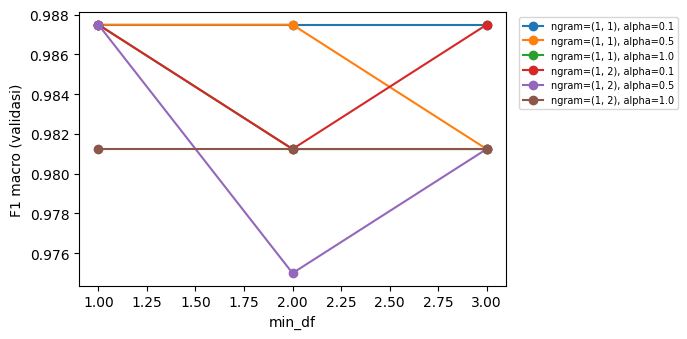

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3.5))
for ngram, group in tfidf_results.groupby("ngram_range"):
    pivot = group.pivot(index="min_df", columns="alpha",
                        values="rata-rata F1 macro")
    for alpha in pivot.columns:
        ax.plot(pivot.index, pivot[alpha], marker="o",
                label=f"ngram={ngram}, alpha={alpha}")
ax.set_xlabel("min_df")
ax.set_ylabel("F1 macro (validasi)")
ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Feature Representation 2: Skip-gram (Word2Vec)

Skip-gram adalah salah satu mode pelatihan pada Word2Vec: model diberi satu
kata target, lalu dilatih menebak kata-kata di sekitarnya (lawannya, mode
CBOW, bekerja sebaliknya: menebak kata target dari kata-kata sekitarnya).
Lewat proses belajar menebak ini, setiap kata akhirnya mendapat satu vektor
angka. Kata yang sering muncul pada konteks kalimat yang mirip akan punya
vektor yang berdekatan secara matematis, meskipun ejaannya sama sekali
berbeda. Inilah yang membedakannya dari TF-IDF, yang hanya menghitung
kemunculan kata tanpa memperhatikan makna atau konteksnya.

Karena Word2Vec memberi vektor per **kata**, bukan per **dokumen**, dibutuhkan
satu langkah tambahan: vektor seluruh kata dalam satu artikel dirata-ratakan
menjadi satu vektor yang mewakili keseluruhan dokumen. Pendekatan rata-rata
ini sederhana dan umum dipakai sebagai baseline, meski pasti ada informasi
urutan kata yang hilang.

Karena hasil rata-rata vektor bisa bernilai negatif (tidak seperti hitungan
TF-IDF yang selalu positif), model yang dipasangkan adalah **Gaussian Naive
Bayes**, varian Naive Bayes untuk data angka kontinu.

### Custom Pipeline Component

`GridSearchCV` dan `Pipeline` dari scikit-learn dirancang untuk komponen yang
punya metode `fit` dan `transform`. Word2Vec dari gensim tidak punya bentuk
seperti itu secara langsung, jadi dibungkus menjadi kelas `SkipGramVectorizer`
buatan sendiri:

- `fit(X)` melatih model Word2Vec pada kumpulan dokumen (list token) yang
  diberikan.
- `transform(X)` mengubah tiap dokumen menjadi satu vektor, dengan
  merata-ratakan vektor kata-kata penyusunnya. Kata yang tidak dikenali model
  (misalnya muncul di data uji tapi tidak pernah muncul di data latih) diabaikan
  dari rata-rata; kalau semua kata dalam dokumen tidak dikenali, dipakai
  vektor nol sebagai pengganti.

Dengan dibungkus seperti ini, Skip-gram bisa diperlakukan sama seperti
TF-IDF: masuk ke dalam `Pipeline` dan ikut dicari parameter terbaiknya lewat
`GridSearchCV`.

In [28]:
import numpy as np
from gensim.models import Word2Vec
from sklearn.base import BaseEstimator, TransformerMixin


class SkipGramVectorizer(BaseEstimator, TransformerMixin):
    """Melatih Word2Vec mode skip-gram pada data yang diberikan ke fit(),
    lalu mengubah tiap dokumen menjadi rata-rata vektor kata penyusunnya."""

    def __init__(self, vector_size=100, window=5, min_count=2, epochs=20):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.epochs = epochs

    def fit(self, X, y=None):
        self.model_ = Word2Vec(
            sentences=X, vector_size=self.vector_size, window=self.window,
            min_count=self.min_count, sg=1, epochs=self.epochs, seed=42,
        )
        return self

    def transform(self, X):
        vecs = []
        for tokens in X:
            word_vecs = [self.model_.wv[w] for w in tokens
                         if w in self.model_.wv]
            vecs.append(np.mean(word_vecs, axis=0) if word_vecs
                        else np.zeros(self.vector_size))
        return np.vstack(vecs)

### Sanity Check: Apakah Vektor Kata Masuk Akal?

Sebelum masuk ke grid search penuh, satu model Word2Vec kecil dilatih sebagai
pengecekan sederhana: apakah kata-kata yang semestinya mirip makna memang
muncul berdekatan menurut model, misalnya kata terkait sport dengan sport
lain, atau kata terkait finance dengan finance lain. Kalau hasilnya acak
sama sekali, berarti ada yang salah dalam data token sebelum lanjut ke
tahap berikutnya.

In [29]:
check_model = Word2Vec(sentences=X_train_tok, vector_size=100, window=5,
                       min_count=2, sg=1, epochs=20, seed=42)

sample_words = [w for w in ["tim", "saham", "poin", "bank"]
                if w in check_model.wv]
rows = []
for w in sample_words:
    neighbors = check_model.wv.most_similar(w, topn=5)
    rows.append({"kata": w,
                 "lima kata terdekat": ", ".join(f"{n} ({s:.2f})"
                                                 for n, s in neighbors)})
pd.DataFrame(rows)

,kata,lima kata terdekat
0,tim,"pencari (0.67), bakat (0.65), hastomo (0.63), ..."
1,saham,"analisis (0.82), artikel (0.81), rekomendasi (..."
2,poin,"asis (0.85), rebound (0.84), prosper (0.80), k..."
3,bank,"sentral (0.88), federal (0.82), msci (0.79), m..."


### Hyperparameter Search Setup (Skip-gram)

Tiga parameter dicari kombinasi terbaiknya:

| Parameter | Arti | Pilihan yang dicoba |
|---|---|---|
| `skipgram__vector_size` | Panjang vektor tiap kata. Makin besar, makin detail representasinya, tapi butuh lebih banyak data supaya tidak terlalu random | `50`, `100` |
| `skipgram__window` | Seberapa jauh kata tetangga yang dianggap sebagai "konteks" saat melatih | `3`, `5` |
| `nb__var_smoothing` | Pemulus pada Gaussian Naive Bayes, serupa `alpha` pada Multinomial, tapi untuk data kontinu | `1e-9`, `1e-7`, `1e-5` |

Skema evaluasinya sama persis dengan TF-IDF: 5-fold cross-validation pada
data latih, diukur dengan F1 macro, supaya kedua representasi fitur
dibandingkan dengan cara yang setara.

In [37]:
from sklearn.naive_bayes import GaussianNB

skipgram_pipe = Pipeline([
    ("skipgram", SkipGramVectorizer()),
    ("nb", GaussianNB()),
])

skipgram_param_grid = {
    "skipgram__vector_size": [50, 100],
    "skipgram__window": [3, 5],
    "nb__var_smoothing": [1e-9, 1e-7, 1e-5],
}

skipgram_search = GridSearchCV(
    skipgram_pipe, skipgram_param_grid, cv=5, scoring="f1_macro", n_jobs=-1,
)
skipgram_search.fit(X_train_tok, y_train)

pd.DataFrame({
    "metrik": ["kombinasi dicoba", "parameter terbaik",
               "skor validasi terbaik (F1 macro)"],
    "nilai": [len(skipgram_search.cv_results_["params"]),
              str(skipgram_search.best_params_),
              f"{skipgram_search.best_score_:.4f}"],
})

,metrik,nilai
0,kombinasi dicoba,12
1,parameter terbaik,"{'nb__var_smoothing': 1e-09, 'skipgram__vector..."
2,skor validasi terbaik (F1 macro),0.9812


### Grid Search Results (Skip-gram)

In [38]:
skipgram_results = pd.DataFrame(skipgram_search.cv_results_)[
    ["param_skipgram__vector_size", "param_skipgram__window",
     "param_nb__var_smoothing", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)
skipgram_results.columns = ["vector_size", "window", "var_smoothing",
                            "rata-rata F1 macro", "std F1 macro"]
skipgram_results.reset_index(drop=True)

,vector_size,window,var_smoothing,rata-rata F1 macro,std F1 macro
0,100,5,1.000000e-09,0.981232,0.015324
1,50,3,1.000000e-09,0.981195,0.025089
2,50,5,1.000000e-09,0.981195,0.025089
3,100,5,1.000000e-05,0.974976,0.012512
4,50,5,1.000000e-05,0.974976,0.036479
5,50,5,1.000000e-07,0.974939,0.023467
6,50,3,1.000000e-05,0.974939,0.023467
7,50,3,1.000000e-07,0.968683,0.019842
8,100,5,1.000000e-07,0.968683,0.019842
9,100,3,1.000000e-07,0.962390,0.023487


## Test Set Evaluation

Dua model terbaik (hasil `best_estimator_` dari masing-masing grid search)
diuji pada 20% data yang sama sekali belum pernah dilihat, baik saat
pelatihan maupun saat validasi di grid search. Ini penting karena skor
validasi tadi hanya menunjukkan performa pada data latih yang dibagi-bagi
sendiri; skor di data uji yang baru inilah yang mencerminkan performa yang
wajar diharapkan pada artikel baru di dunia nyata.

In [32]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

pred_tfidf = tfidf_search.predict(X_test_text)
pred_skipgram = skipgram_search.predict(X_test_tok)

report_tfidf = classification_report(y_test, pred_tfidf, output_dict=True)
report_skipgram = classification_report(y_test, pred_skipgram,
                                        output_dict=True)

comparison = pd.DataFrame({
    "representasi": ["TF-IDF + MultinomialNB", "Skip-gram + GaussianNB"],
    "akurasi": [accuracy_score(y_test, pred_tfidf),
                accuracy_score(y_test, pred_skipgram)],
    "F1 macro": [f1_score(y_test, pred_tfidf, average="macro"),
                 f1_score(y_test, pred_skipgram, average="macro")],
    "precision sport": [report_tfidf["sport"]["precision"],
                        report_skipgram["sport"]["precision"]],
    "recall sport": [report_tfidf["sport"]["recall"],
                     report_skipgram["sport"]["recall"]],
    "F1 sport": [report_tfidf["sport"]["f1-score"],
                 report_skipgram["sport"]["f1-score"]],
    "precision finance": [report_tfidf["finance"]["precision"],
                          report_skipgram["finance"]["precision"]],
    "recall finance": [report_tfidf["finance"]["recall"],
                       report_skipgram["finance"]["recall"]],
    "F1 finance": [report_tfidf["finance"]["f1-score"],
                   report_skipgram["finance"]["f1-score"]],
})
comparison

,representasi,akurasi,F1 macro,precision sport,recall sport,F1 sport,precision finance,recall finance,F1 finance
0,TF-IDF + MultinomialNB,1.000,1.000000,1.0,1.00,1.000000,1.000000,1.0,1.000000
1,Skip-gram + GaussianNB,0.925,0.924576,1.0,0.85,0.918919,0.869565,1.0,0.930233


### Metric Comparison Chart

Akurasi dan F1 macro kedua model digambar berdampingan supaya selisihnya
mudah terlihat sekilas.

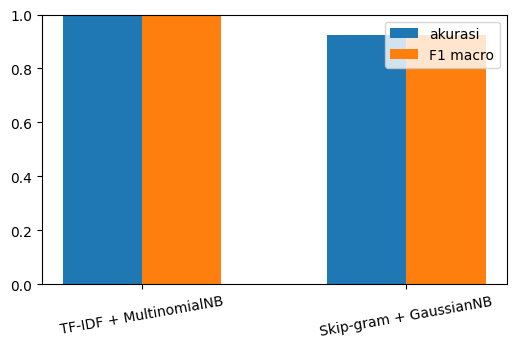

In [39]:
fig, ax = plt.subplots(figsize=(6, 3.5))
x = range(len(comparison))
ax.bar([i - 0.15 for i in x], comparison["akurasi"], width=0.3,
       label="akurasi")
ax.bar([i + 0.15 for i in x], comparison["F1 macro"], width=0.3,
       label="F1 macro")
ax.set_xticks(list(x))
ax.set_xticklabels(comparison["representasi"], rotation=10)
ax.set_ylim(0, 1)
ax.legend()
plt.show()

### Confusion Matrix

Confusion matrix menunjukkan rincian kesalahan: dari artikel yang sebenarnya
sport, berapa yang ditebak benar sebagai sport dan berapa yang salah ditebak
finance (begitu juga sebaliknya). Ini memberi gambaran lebih detail daripada
sekadar satu angka akurasi.

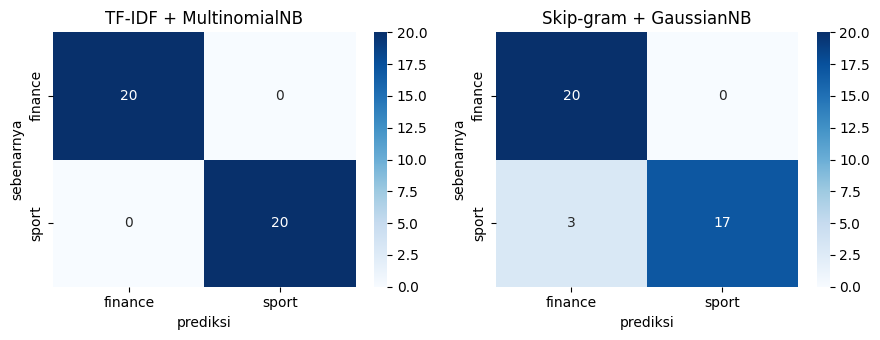

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
labels_order = sorted(y_test.unique())
for ax, pred, title in zip(
    axes, [pred_tfidf, pred_skipgram],
    ["TF-IDF + MultinomialNB", "Skip-gram + GaussianNB"],
):
    cm = confusion_matrix(y_test, pred, labels=labels_order)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=labels_order, yticklabels=labels_order)
    ax.set_title(title)
    ax.set_xlabel("prediksi")
    ax.set_ylabel("sebenarnya")
plt.tight_layout()
plt.show()

### Error Analysis

Artikel yang salah diklasifikasikan oleh masing-masing model ditampilkan
sebagai contoh konkret. Melihat isi artikel yang salah tebak sering membantu
memahami *mengapa* sebuah model keliru, bukan cuma *berapa banyak* dia keliru.

In [36]:
test_ids = df.loc[y_test.index, "id"]
errors = pd.DataFrame({
    "id": test_ids.values,
    "label asli": y_test.values,
    "prediksi TF-IDF": pred_tfidf,
    "prediksi Skip-gram": pred_skipgram,
    "cuplikan teks": [t[:80] + "..." for t in
                      df.loc[y_test.index, "isi_berita"]],
})
errors[(errors["label asli"] != errors["prediksi TF-IDF"]) |
       (errors["label asli"] != errors["prediksi Skip-gram"])]

,id,label asli,prediksi TF-IDF,prediksi Skip-gram,cuplikan teks
10,8,sport,sport,finance,Foto Sport Serunya 549 Siswa di Ciamis Adu Ket...
22,23,sport,sport,finance,ALTI DKI Jakarta Target 5 Emas di PON 2028 Aso...
28,34,sport,sport,finance,Hyrox Akhirnya Minta Maaf soal Insiden Atlet C...


## Model Selection

Model dengan **F1 macro** tertinggi di data uji dipilih sebagai model final.
F1 macro dipakai sebagai acuan utama, bukan sekadar akurasi, karena F1 macro
menilai performa di kedua label secara setara. Akurasi saja bisa menyesatkan
kalau salah satu label ternyata lebih mudah ditebak daripada yang lain.

In [41]:
if comparison.loc[0, "F1 macro"] >= comparison.loc[1, "F1 macro"]:
    best_name = "TF-IDF + MultinomialNB"
    best_model = tfidf_search.best_estimator_
    best_params = tfidf_search.best_params_
    best_pred = pred_tfidf
else:
    best_name = "Skip-gram + GaussianNB"
    best_model = skipgram_search.best_estimator_
    best_params = skipgram_search.best_params_
    best_pred = pred_skipgram

pd.DataFrame({
    "metrik": ["model terpilih", "parameter terbaik", "F1 macro (uji)",
               "akurasi (uji)"],
    "nilai": [best_name, str(best_params),
              f"{comparison['F1 macro'].max():.4f}",
              f"{accuracy_score(y_test, best_pred):.4f}"],
})

,metrik,nilai
0,model terpilih,TF-IDF + MultinomialNB
1,parameter terbaik,"{'nb__alpha': 0.1, 'tfidf__min_df': 1, 'tfidf_..."
2,F1 macro (uji),1.0000
3,akurasi (uji),1.0000


In [42]:
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

     finance       1.00      1.00      1.00        20
       sport       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



## Saving the Model

Pipeline lengkap (langkah representasi fitur digabung dengan Naive Bayes)
disimpan menjadi satu berkas `.joblib`. Dengan begini, langkah representasi
fitur dan model ikut tersimpan sebagai satu kesatuan: pemakaian ulang nanti
tidak perlu melatih ulang TF-IDF atau Word2Vec dari awal, cukup muat berkasnya
dan panggil `.predict()`. Teks artikel baru tetap perlu melewati tahapan
`strip_boilerplate` → `protect` → `normalize_letters` → `guarded_replace` →
`strip_punct` → buang stopword → `stem_tokens` terlebih dulu, karena tahap
itu belum termasuk dalam pipeline yang disimpan.

In [48]:
import joblib
import os

# Buat folder models di dalam project
os.makedirs("models", exist_ok=True)

slug = best_name.split()[0].lower().replace("-", "")

# f-string agar {slug} diganti dengan nilai sebenarnya
model_path = f"models/best_model_{slug}.joblib"

# Simpan model
joblib.dump(best_model, model_path)

pd.DataFrame({
    "berkas": [model_path],
    "ukuran (KB)": [
        round(os.path.getsize(model_path) / 1024, 1)
    ],
})

,berkas,ukuran (KB)
0,models/best_model_tfidf.joblib,228.2


## Conclusion

In [49]:
from IPython.display import Markdown, display


def desimal(x, d=4):
    return f"{x:.{d}f}".replace(".", ",")


display(Markdown(f"""Dari {len(docs_tokens)} artikel yang telah dibersihkan
melalui tujuh tahap (boilerplate removal, format protection, letter
normalization, slang standardization, punctuation stripping, stopword
removal, stemming dengan name protection), {len(X_train_tok)} dokumen dipakai
untuk melatih dan mencari parameter terbaik, sedangkan {len(X_test_tok)}
dokumen lainnya sama sekali tidak disentuh sampai tahap evaluasi akhir.

Dua representasi fitur diuji dengan Naive Bayes:

- **TF-IDF + MultinomialNB** mencapai F1 macro {desimal(comparison.loc[0, 'F1 macro'])}
  di data uji, dengan parameter terbaik {tfidf_search.best_params_}.
- **Skip-gram + GaussianNB** mencapai F1 macro {desimal(comparison.loc[1, 'F1 macro'])}
  di data uji, dengan parameter terbaik {skipgram_search.best_params_}.

Kedua parameter ditemukan lewat grid search 5-fold yang hanya melihat data
latih, sehingga skor di data uji murni mengukur generalisasi ke artikel yang
belum pernah dilihat, bukan hasil menghafal. Model terpilih sebagai hasil
akhir adalah **{best_name}**, dan telah disimpan ke `{model_path}` agar siap
dipakai ulang tanpa pelatihan dari awal."""))

Dari 200 artikel yang telah dibersihkan
melalui tujuh tahap (boilerplate removal, format protection, letter
normalization, slang standardization, punctuation stripping, stopword
removal, stemming dengan name protection), 160 dokumen dipakai
untuk melatih dan mencari parameter terbaik, sedangkan 40
dokumen lainnya sama sekali tidak disentuh sampai tahap evaluasi akhir.

Dua representasi fitur diuji dengan Naive Bayes:

- **TF-IDF + MultinomialNB** mencapai F1 macro 1,0000
  di data uji, dengan parameter terbaik {'nb__alpha': 0.1, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}.
- **Skip-gram + GaussianNB** mencapai F1 macro 0,9246
  di data uji, dengan parameter terbaik {'nb__var_smoothing': 1e-09, 'skipgram__vector_size': 100, 'skipgram__window': 5}.

Kedua parameter ditemukan lewat grid search 5-fold yang hanya melihat data
latih, sehingga skor di data uji murni mengukur generalisasi ke artikel yang
belum pernah dilihat, bukan hasil menghafal. Model terpilih sebagai hasil
akhir adalah **TF-IDF + MultinomialNB**, dan telah disimpan ke `models/best_model_tfidf.joblib` agar siap
dipakai ulang tanpa pelatihan dari awal.

## Deployment

Setelah model terbaik berhasil dipilih dan disimpan, langkah selanjutnya
adalah membuatnya dapat diakses dan digunakan oleh pengguna melalui
antarmuka web yang sederhana. Untuk tujuan ini, library Streamlit dipilih
karena kemudahannya dalam mengubah skrip Python menjadi aplikasi web
interaktif tanpa perlu menulis HTML, CSS, atau JavaScript secara terpisah.

Proses implementasi dimulai dengan menginstal Streamlit beserta dependensi
pendukung lainnya (`trafilatura` untuk crawling otomatis, `joblib` untuk
memuat model) melalui `pip install -r requirements.txt`. Kemudian, sebuah
file Python baru bernama `app.py` dibuat sebagai pusat dari aplikasi web,
didampingi `preprocessing.py` yang berisi ulang seluruh fungsi pembersihan
teks dari notebook ini, supaya teks yang masuk ke model diproses dengan
cara yang identik antara tahap pelatihan dan tahap deploy.

Di dalam `app.py`, pipeline TF-IDF + Multinomial Naive Bayes yang
sebelumnya telah disimpan (`.joblib`) dimuat kembali. Dengan menggunakan
fungsi-fungsi dari Streamlit, dibuatlah sebuah antarmuka pengguna yang
terdiri dari beberapa bagian:

* **Form Input** — sebuah kolom teks di mana pengguna cukup menempelkan
  URL artikel berita (misalnya dari detik.com), tanpa perlu menyalin isi
  artikel secara manual.
* **Proses Otomatis di Balik Layar** — begitu tombol diklik, aplikasi
  mengambil isi artikel dari URL tersebut menggunakan `trafilatura`,
  membersihkan teksnya lewat alur yang sama seperti pada notebook ini
  (boilerplate removal, normalisasi huruf, standardisasi slang, stopword
  removal, hingga stemming dengan perlindungan nama diri), lalu
  mengubahnya menjadi vektor TF-IDF di dalam pipeline yang sudah dimuat.
* **Tampilan Hasil** — aplikasi menampilkan label prediksi (`sport` atau
  `finance`) beserta tingkat keyakinan model untuk masing-masing label,
  sehingga pengguna juga bisa melihat seberapa yakin model terhadap
  prediksinya, bukan hanya label akhirnya saja.

Seluruh kode untuk membangun tampilan web ini ditulis di dalam `app.py` dan
`preprocessing.py`, menunjukkan kekuatan dan kesederhanaan Streamlit dalam
menyajikan hasil kerja machine learning sebagai produk yang bisa langsung
dicoba siapa saja lewat browser.

* **Source Code**: Kode lengkap untuk aplikasi web ini dapat diakses
  melalui repositori GitHub: (<https://github.com/ZulfRizz/uts-ppw-klasifikasi-berita>)
* **Aplikasi Web**: Hasil akhir dari implementasi ini dapat diakses dan
  dicoba secara langsung melalui tautan berikut: <(https://uts-ppw-klasifikasi-berita.streamlit.app/)>

Berikut adalah hasil dari webnya. Terdapat form untuk memasukkan URL
artikel yang nantinya akan diambil isinya secara otomatis dan
diklasifikasikan: